# 1. LSTM Model Base Overview
----------------

This notebook implements a Long Short-Term Memory (LSTM) based recommendation model.

**Key Aspects:**
*   **Splitting Strategy:** Utilizes a k-2, k-1, k split for training, validation, and testing.
*   **Objective:** Predict the next item in a user's recommendation sequence.
*   **Embeddings:** Incorporates `item_semantic_embedding_static` derived from book title, description, and top shelf tags.
*   **Loss Function:** Uses BPR (Bayesian Personalized Ranking) Loss for optimisation.
*   **Negative Sampling:** Includes hard negative sampling with a popularity fallback.

# 2. Imports

In [ ]:
import pandas as pd
import numpy as np
from collections import defaultdict
import torch
import random
from torch.utils.data import Dataset
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/BT4222Project/final_updated_baseline_df.pkl'
full_df = pd.read_pickle(file_path)

Mounted at /content/drive


# 3. Metrics used in the model
- Hit Rate: Was the subsequent(target) book recommended in the top K
- MAP/NDCG: Was the subsequent(target) book ranked high in the top K

In [ ]:
def hit_rate(preds, targets, k=10):
    """
    preds: numpy array of shape (batch_size, num_items), predicted scores
    targets: numpy array of shape (batch_size,), true item indices
    """
    top_k = np.argsort(-preds, axis=1)[:, :k]
    hits = [t in top for t, top in zip(targets, top_k)]
    return np.mean(hits)

def map_at_k(preds, targets, k=10):
    top_k = np.argsort(-preds, axis=1)[:, :k]
    ap_list = []
    for t, top in zip(targets, top_k):
        if t in top:
            rank = np.where(top == t)[0][0] + 1  # 1-based
            ap_list.append(1.0 / rank)
        else:
            ap_list.append(0.0)
    return np.mean(ap_list)

def ndcg_at_k(preds, targets, k=10):
    top_k = np.argsort(-preds, axis=1)[:, :k]
    ndcg_list = []
    for t, top in zip(targets, top_k):
        if t in top:
            rank = np.where(top == t)[0][0] + 1
            ndcg_list.append(1.0 / np.log2(rank + 1))
        else:
            ndcg_list.append(0.0)
    return np.mean(ndcg_list)

def calculate_batch_metrics(top_k_indices, targets):
    """
    top_k_indices: numpy array of shape (batch_size, k)
    targets: numpy array of shape (batch_size,)
    Returns the sum of HR, MAP, and NDCG for the batch.
    """
    hits, map_sum, ndcg_sum = 0, 0, 0

    for t, top in zip(targets, top_k_indices):
        if t in top:
            hits += 1
            rank = np.where(top == t)[0][0] + 1
            map_sum += 1.0 / rank
            ndcg_sum += 1.0 / np.log2(rank + 1)

    return hits, map_sum, ndcg_sum

# 4. Index Representation for Embeddings

This section details the creation of numerical index representations for users and books, used for embedding layers in the model.

In [ ]:
# Shifted +1 to reserve 0 for padding when interaction sequence was created
user2idx = {u: i + 1 for i, u in enumerate(full_df['user_id'].unique())}
book2idx = {b: i + 1 for i, b in enumerate(full_df['book_id'].unique())}

full_df['user_idx'] = full_df['user_id'].map(user2idx)
full_df['book_idx'] = full_df['book_id'].map(book2idx)

num_users = len(user2idx)
num_books = len(book2idx)

# Build full user sequences in chronological order
def build_user_sequences(df):
    user_seq = defaultdict(list)

    for user, group in df.groupby('user_idx'):
        user_seq[user] = group.index.tolist()
    return user_seq

full_seq = build_user_sequences(full_df)

# 5. Data Splitting Strategy

The dataset is split into training, validation, and test sets using a time-aware approach. For each user's sequence of interactions, the following splits are applied:

*   **Training Set**: Includes all interactions up to the third-to-last item (k-2).
*   **Validation Set**: Used for predicting the second-to-last item (k-1).
*   **Test Set**: Used for predicting the last item (k).

In [ ]:
# Split sequences into k-2, k-1, k
train_seq, val_seq, test_seq = {}, {}, {}

# Grouped the user
for user, seq in full_seq.items():
    if len(seq) < 3:
        continue

    train_seq[user] = seq[:-2]
    val_seq[user] = seq[:-1]
    test_seq[user] = seq

# 6. Negative Sampling Fallback: Identifying Popular Items

In [ ]:
top_1000_books = full_df['book_idx'].value_counts().head(1000).index.tolist()
print(f"Identified {len(top_1000_books)} popular items for fallback sampling.")

Identified 1000 popular items for fallback sampling.


# 7. Sequential Dataset and DataLoader Configuration

This section outlines the creation of the `SequentialBookRecDataset` and its configuration. Key parameters include:

*   **Context Window**: Sequences are limited to a length of 10, capturing the most recent interactions for prediction.
*   **Padding Strategy**: Shorter sequences are left-padded with a dedicated padding index (0) to ensure uniform input dimensions for the model.
*   **Hard Negatives**: Samples negative items from user's future interaction such that it is not the next item as negatives, making it more likely negatives than random negative
    - Popularity fallback if no suitable books are found
    - Further fallback to random if user has read all possible popular books

In [ ]:
class SequentialBookRecDataset(Dataset):
    def __init__(self, user_seq, full_user_seq, df, num_books, top_popular_books, seq_len=10, split='train'):
        self.seq_len = seq_len
        self.split = split
        self.df = df
        self.user_seq = user_seq
        self.full_user_history_set = {u: set(seq) for u, seq in full_user_seq.items()}
        self.num_books = num_books
        self.top_popular_books = top_popular_books

        self.books = df['book_idx'].values
        self.static_emb = np.vstack(df['item_semantic_embedding_static'].values)

        self.samples = []
        for user_id, indices in self.user_seq.items():
            n = len(indices)
            if n < 3: continue

            if split == 'train':
                for pos in range(1, n - 2):
                    self.samples.append((user_id, pos))
            elif split == 'val':
                self.samples.append((user_id, n - 2))
            elif split == 'test':
                self.samples.append((user_id, n - 1))

    def __len__(self):
        return len(self.samples)

    def _get_hard_negative(self, user_id, pos):
        indices = self.user_seq[user_id]
        n_current = len(indices)
        valid_future_range = range(pos + 2, n_current)

        if len(valid_future_range) > 0:
            neg_idx_in_split = random.choice(valid_future_range)
            return self.books[indices[neg_idx_in_split]]

        # Fallback to sampling from top 1000 popular items to increase 'difficulty'
        # We attempt up to 10 times to find a popular item the user hasn't seen
        for _ in range(10):
            neg_item = random.choice(self.top_popular_books)
            if neg_item not in self.full_user_history_set[user_id]:
                return neg_item

        # Final fallback to true random if the user has seen all top 1000
        while True:
            neg_item = random.randint(1, self.num_books)
            if neg_item not in self.full_user_history_set[user_id]:
                return neg_item

    def __getitem__(self, idx):
        user_id, pos = self.samples[idx]
        indices = self.user_seq[user_id]
        start = max(0, pos - self.seq_len)
        seq_idx = indices[start:pos]

        actual_book_ids = self.books[seq_idx]
        actual_static_emb = self.static_emb[seq_idx]
        target_book_id = self.books[indices[pos]]

        pad_len = self.seq_len - len(seq_idx)
        if pad_len > 0:
            pad_books = np.zeros(pad_len, dtype=int)
            pad_embs = np.zeros((pad_len, actual_static_emb.shape[1]), dtype=np.float32)
            actual_book_ids = np.concatenate([pad_books, actual_book_ids])
            actual_static_emb = np.concatenate([pad_embs, actual_static_emb])

        neg_target_book_id = self._get_hard_negative(user_id, pos)

        return {
            'seq_book_ids': torch.LongTensor(actual_book_ids),
            'seq_static_emb': torch.FloatTensor(actual_static_emb),
            'user_id': torch.LongTensor([user_id]),
            'target': torch.LongTensor([target_book_id]),
            'neg_target': torch.LongTensor([neg_target_book_id])
        }

# 8. DataLoader Creation
This section initializes the `DataLoader` objects for the training, validation, and test datasets, facilitating efficient batch processing during model training and evaluation.

In [ ]:
train_dataset = SequentialBookRecDataset(train_seq, full_seq, full_df, num_books, top_1000_books, split='train')
val_dataset   = SequentialBookRecDataset(val_seq, full_seq, full_df, num_books, top_1000_books, split='val')
test_dataset  = SequentialBookRecDataset(test_seq, full_seq, full_df, num_books, top_1000_books, split='test')

train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True, num_workers=3)
val_loader   = DataLoader(val_dataset, batch_size=2048, shuffle=False, num_workers=3)
test_loader  = DataLoader(test_dataset, batch_size=2048, shuffle=False, num_workers=3)

# 9. Sequential Model Definition
This section defines the architecture of the LSTM-based`SequentialBookRecModel`

**Key Specifications:**
*   **Architecture:** Utilizes an LSTM layer followed by two hidden layers in a Feed-Forward Network (FFN).
*   **Dropout:** A dropout rate of 0.3 is applied to prevent overfitting.

In [ ]:
class SequentialBookRecModel(nn.Module):
    def __init__(self,
                 num_users,
                 num_books,
                 book_emb_dim=64,
                 user_emb_dim=16,
                 lstm_hidden_dim=128,
                 lstm_layers=1,
                 seq_len=10,
                 static_emb_dim=384,
                 dropout=0.3):

        super().__init__()
        self.seq_len = seq_len

        # Embeddings: num_books + 1 to account for 0 as padding and 1..num_books as items
        self.book_emb = nn.Embedding(num_books + 1, book_emb_dim, padding_idx=0)
        self.user_emb = nn.Embedding(num_users + 1, user_emb_dim, padding_idx=0)

        # LSTM
        total_seq_emb_dim = book_emb_dim + static_emb_dim
        self.lstm = nn.LSTM(input_size = total_seq_emb_dim,
                            hidden_size = lstm_hidden_dim,
                            num_layers = lstm_layers,
                            batch_first = True)

        self.dropout = nn.Dropout(dropout)
        ffn_input_dim = lstm_hidden_dim + user_emb_dim

        self.ffn = nn.Sequential(
            nn.Linear(ffn_input_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_books + 1) # Output size num_books + 1 matches indices
        )

    def forward(self, seq_book_ids, seq_static_emb, user_id):
        # Sequence embeddings
        book_emb = self.book_emb(seq_book_ids)
        seq_input = torch.cat([book_emb, seq_static_emb], dim=-1)

        lstm_out, _ = self.lstm(seq_input)
        lstm_out = lstm_out[:, -1, :]
        lstm_out = self.dropout(lstm_out)

        user_id = user_id.squeeze(1)
        user_emb = self.user_emb(user_id)

        x = torch.cat([lstm_out, user_emb], dim=-1)
        logits = self.ffn(x)
        return logits

# 10. BPR Loss Function
This section defines the Bayesian Personalized Ranking (BPR) Loss function.

BPR maximises the difference between the predicted scores of positive (next book in the sequence) books and negative (non-next book in the sequence) books, thereby optimising for personalised ranking.

In [ ]:
class BPRLoss(nn.Module):
    def __init__(self):
        super(BPRLoss, self).__init__()

    def forward(self, pos_scores, neg_scores):
        """
        pos_scores: Model's predicted score for the actual next book
        neg_scores: Model's predicted score for a randomly sampled unread book
        """
        # BPR Loss Formula : -mean(log(sigmoid(pos_scores - neg_scores)))
        loss = -torch.mean(F.logsigmoid(pos_scores - neg_scores))
        return loss



# 11. Model Initialization and Configuration

This section initialises the `SequentialBookRecModel` with specified parameters.

**Configuration:**
*   **Loss Function:**: (`Bayesian Personalised Ranking`)
*   **Optimiser:**: (`Adam`) with weight decay for L2 Regularisaion

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = SequentialBookRecModel(
    num_users=num_users,
    num_books=num_books,
    book_emb_dim=64,
    user_emb_dim=16,
    lstm_hidden_dim=128,
    seq_len=10,
    static_emb_dim=full_df['item_semantic_embedding_static'].iloc[0].shape[0] # Obtain dimension
).to(device)

criterion = BPRLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

# 12. Model Training Function

This section defines the `train_model` function, which orchestrates the training and validation loops, calculates performance metrics, and plots the training progress and rank distributions.

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=10, device='cuda'):
    train_losses, val_losses = [], []
    hr_list, map_list, ndcg_list = [], [], []
    all_epoch_ranks = []

    for epoch in range(epochs):
        # ==========================================
        # 1. TRAINING PHASE
        # ==========================================
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
            optimizer.zero_grad()
            logits = model(
                batch['seq_book_ids'].to(device),
                batch['seq_static_emb'].to(device),
                batch['user_id'].to(device)
            )
            targets = batch['target'].squeeze(1).to(device)
            neg_targets = batch['neg_target'].squeeze(1).to(device)

            batch_indices = torch.arange(logits.size(0)).to(device)
            pos_scores = logits[batch_indices, targets]
            neg_scores = logits[batch_indices, neg_targets]

            # Pass all necessary arguments to the HybridLoss criterion
            loss = criterion(pos_scores, neg_scores, logits, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ==========================================
        # 2. VALIDATION PHASE
        # ==========================================
        model.eval()
        val_loss, total_hits, total_map, total_ndcg, num_val_samples = 0, 0, 0, 0, 0
        current_epoch_ranks = []

        with torch.no_grad():
            for batch in val_loader:
                logits = model(
                    batch['seq_book_ids'].to(device),
                    batch['seq_static_emb'].to(device),
                    batch['user_id'].to(device)
                )
                targets = batch['target'].squeeze(1).to(device)
                neg_targets = batch['neg_target'].squeeze(1).to(device)

                # Calculate Hybrid Validation Loss
                batch_indices = torch.arange(logits.size(0)).to(device)
                pos_scores = logits[batch_indices, targets]
                neg_scores = logits[batch_indices, neg_targets]
                batch_loss = criterion(pos_scores, neg_scores, logits, targets)
                val_loss += batch_loss.item()

                # Get top 20 to calculate hits and near-misses
                _, top_indices = torch.topk(logits, k=20, dim=1)
                targets_np = targets.cpu().numpy()
                top_indices_np = top_indices.cpu().numpy()

                batch_hits, batch_map, batch_ndcg = calculate_batch_metrics(top_indices_np[:, :10], targets_np)
                total_hits += batch_hits
                total_map += batch_map
                total_ndcg += batch_ndcg
                num_val_samples += len(targets_np)

                for i in range(len(targets_np)):
                    match = np.where(top_indices_np[i] == targets_np[i])[0]
                    if len(match) > 0:
                        current_epoch_ranks.append(match[0] + 1)
                    else:
                        current_epoch_ranks.append(21)

        all_epoch_ranks.append(current_epoch_ranks)

        # Track Validation Loss
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        hr = total_hits / num_val_samples
        mapk = total_map / num_val_samples
        ndcg = total_ndcg / num_val_samples

        hr_list.append(hr); map_list.append(mapk); ndcg_list.append(ndcg)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | HR@10: {hr:.4f}")

    plot_final_results(train_losses, val_losses, hr_list, map_list, ndcg_list, all_epoch_ranks)

    return model, train_losses, val_losses, hr_list, map_list, ndcg_list

def plot_final_results(train_losses, val_losses, hr_list, map_list, ndcg_list, all_epoch_ranks):
    num_epochs = len(train_losses)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    epochs_range = range(1, num_epochs + 1)

    # 1. Plot Training and Validation Loss
    ax1.plot(epochs_range, train_losses, label='Train Loss', marker='o')
    ax1.plot(epochs_range, val_losses, label='Val Loss', marker='s')
    ax1.set_title('Loss Curves'); ax1.legend(); ax1.grid(True)

    # 2. Plot HR, MAP, and NDCG
    ax2.plot(epochs_range, hr_list, label='HR@10', marker='o')
    ax2.plot(epochs_range, map_list, label='MAP@10', marker='s') # <-- MAP Added Here
    ax2.plot(epochs_range, ndcg_list, label='NDCG@10', marker='^')
    ax2.set_title('Performance Metrics'); ax2.legend(); ax2.grid(True)
    plt.show()

    # 3. Plot Rank Distributions for each epoch in a grid
    cols = 2
    rows = (num_epochs + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
    axes = axes.flatten()

    for i in range(num_epochs):
        ranks = all_epoch_ranks[i]
        bins = np.arange(1, 23)
        counts, _ = np.histogram(ranks, bins=bins)
        props = counts / len(ranks)

        axes[i].bar(range(1, 11), props[:10], color='green')
        axes[i].bar(range(11, 21), props[10:20], color='red')
        axes[i].bar(21, props[20], color='gray')
        axes[i].set_title(f"Epoch {i+1} Rank Distribution")
        axes[i].set_xticks(range(1, 22))
        axes[i].set_xticklabels([str(x) for x in range(1, 21)] + ["20+"])

        for j, p in enumerate(props[:10]):
            if p > 0.05: axes[i].text(j+1, p, f"{p:.2f}", ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()


# 13. Initiate Model Training
This cell executes the `train_model` function to commence the training process for the `SequentialBookRecModel` for 10 epochs

Epoch 1 [Train]: 100%|██████████| 3472/3472 [03:18<00:00, 17.49it/s]


Epoch 1/10 - Train Loss: 0.5492 | Val Loss: 0.4307 | HR@10: 0.1427


Epoch 2 [Train]: 100%|██████████| 3472/3472 [03:16<00:00, 17.65it/s]


Epoch 2/10 - Train Loss: 0.4769 | Val Loss: 0.4122 | HR@10: 0.1569


Epoch 3 [Train]: 100%|██████████| 3472/3472 [03:17<00:00, 17.62it/s]


...

Epoch 8/10 - Train Loss: 0.4265 | Val Loss: 0.4819 | HR@10: 0.1434


Epoch 9 [Train]: 100%|██████████| 3472/3472 [03:16<00:00, 17.66it/s]


Epoch 9/10 - Train Loss: 0.4242 | Val Loss: 0.4731 | HR@10: 0.1457


Epoch 10 [Train]: 100%|██████████| 3472/3472 [03:34<00:00, 16.18it/s]


Epoch 10/10 - Train Loss: 0.4224 | Val Loss: 0.4863 | HR@10: 0.1462


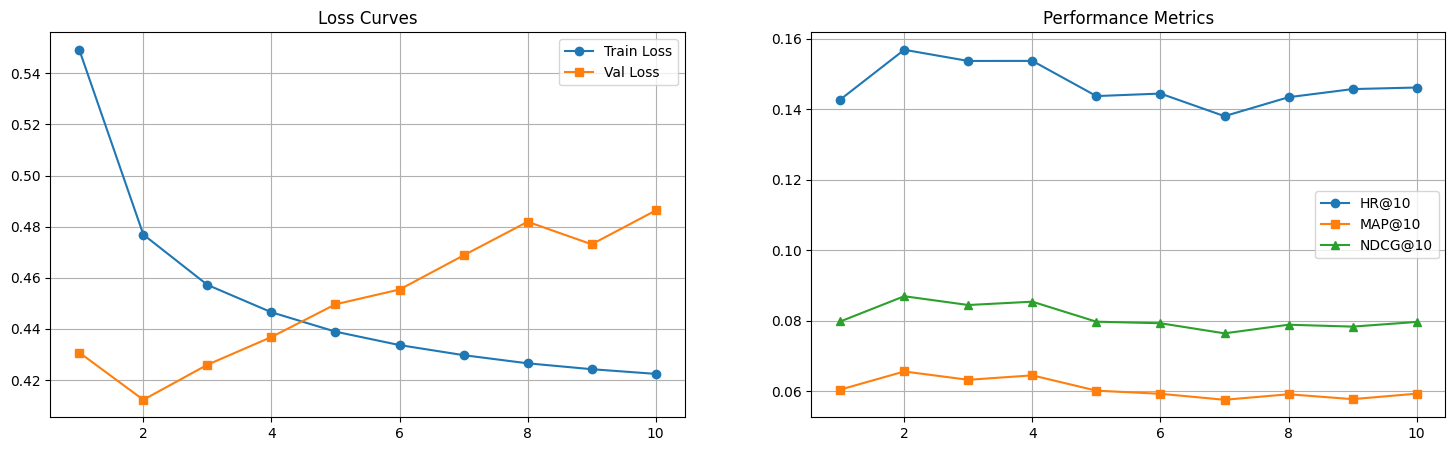

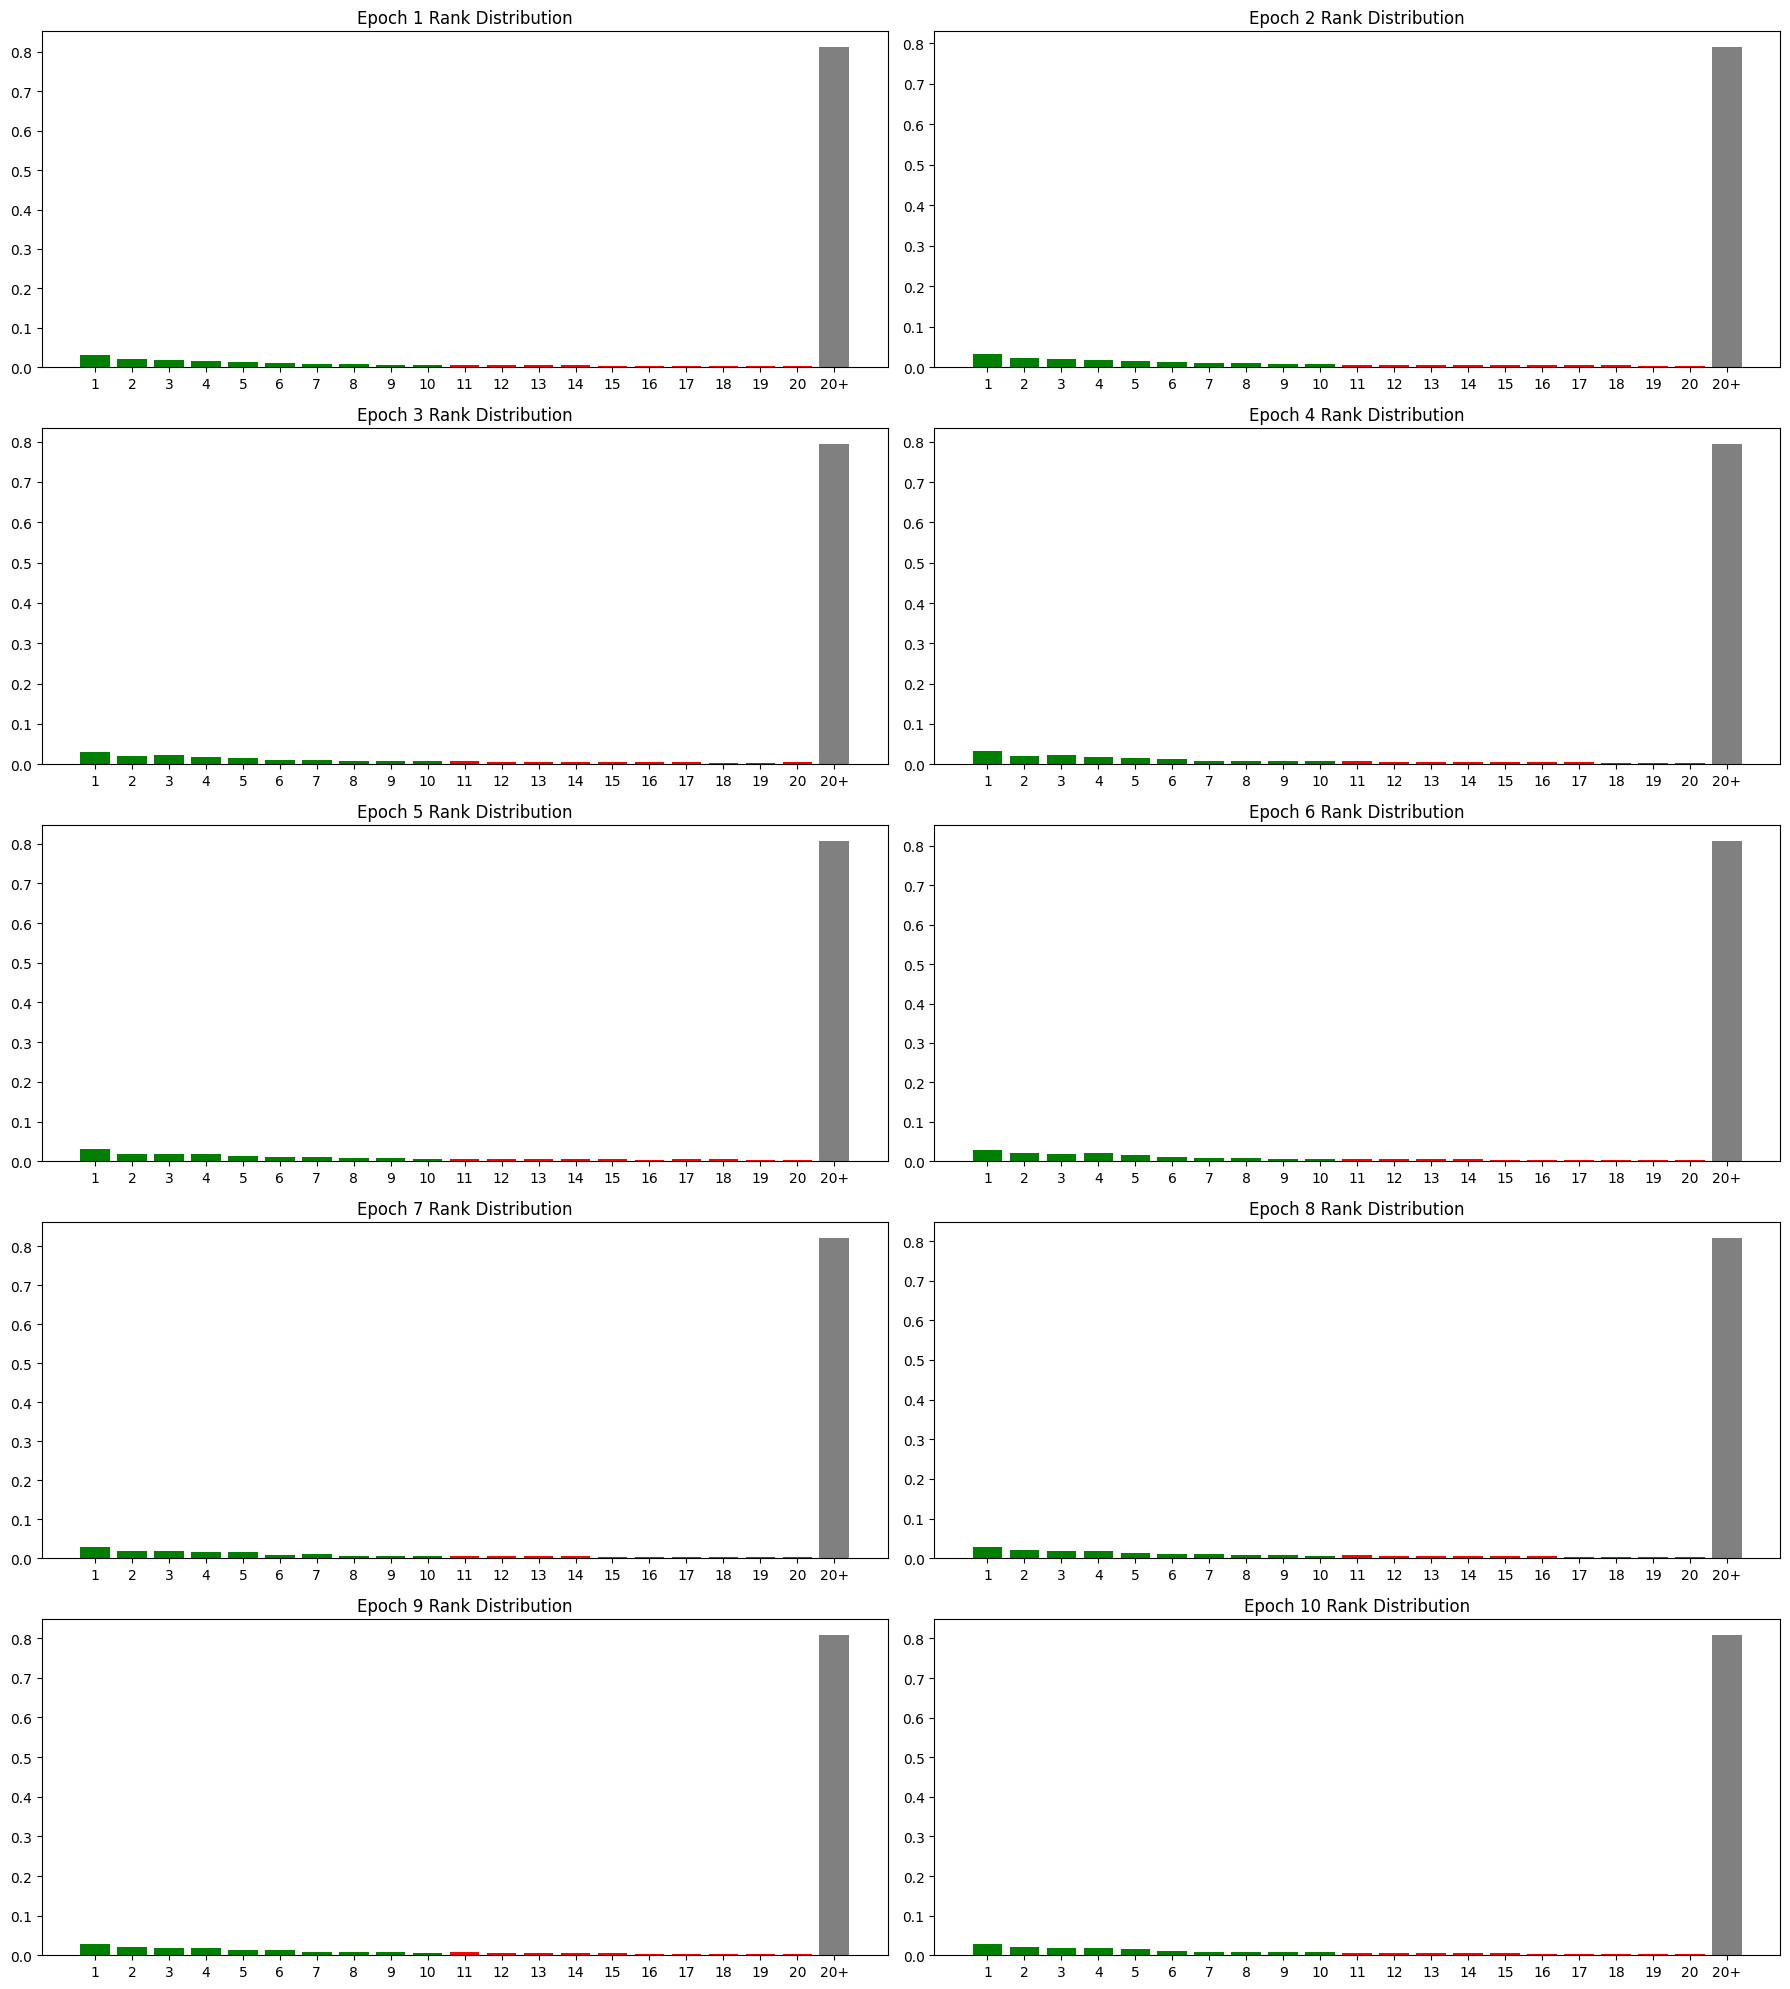

In [ ]:
trained_model = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=10,
    device=device
)

# 14. Model Evaluation on Test Set

This section defines and executes the `evaluate_test` function to assess the final performance of the trained model on the unseen test dataset using metrics such as Hit Rate, MAP, and NDCG.

In [ ]:
def evaluate_test(model, test_loader, device='cuda', k=10):
    model.eval()
    total_hits, total_map, total_ndcg = 0, 0, 0
    num_samples = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating Test Set"):
            logits = model(
                batch['seq_book_ids'].to(device),
                batch['seq_static_emb'].to(device),
                batch['user_id'].to(device)
            )
            targets = batch['target'].squeeze(1).cpu().numpy()

            # Get top k indices directly on device, then move to CPU
            _, top_indices = torch.topk(logits, k=k, dim=1)
            top_indices = top_indices.cpu().numpy()

            batch_hits, batch_map, batch_ndcg = calculate_batch_metrics(top_indices, targets)

            total_hits += batch_hits
            total_map += batch_map
            total_ndcg += batch_ndcg
            num_samples += len(targets)

    metrics = {
        f'HR@{k}': total_hits / num_samples,
        f'MAP@{k}': total_map / num_samples,
        f'NDCG@{k}': total_ndcg / num_samples
    }

    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

    return metrics

# To run the evaluation:
test_results = evaluate_test(model, test_loader, device=device)

Evaluating Test Set: 100%|██████████| 155/155 [00:08<00:00, 18.40it/s]

HR@10: 0.1118
MAP@10: 0.0453
NDCG@10: 0.0608


# 15. Analysis of Model Performance and Bayesian Personalised Ranking Loss Limitations

This section evaluates the baseline model performance and analyses the observed behaviour of Bayesian Personalized Ranking (BPR) loss in comparison to Cross-Entropy optimisation.

Negative sampling strategy used: Hard negatives drawn from future interactions within the user's sequence. Fallback: top-1000 popular books unseen by the user to avoid data leakage while providing informative negatives.

### Observations

After incorporating BPR with sampled negatives, test performance decreased relative to the Cross-Entropy baseline.

* This suggests that while BPR is effective for learning relative item preferences, its performance is more sensitive to the structure of the training signal in semantically rich and temporally correlated recommendation data
* Item representations derived from `item_semantic_embedding_static` introduce a high degree of similarity among possible books, resulting in a more challenging ranking landscape where many books are potentially relevant to the user’s future behaviour.

This makes it more difficult for the model to learn a clear separation between true target items and closely related non-target candidates, as both may exhibit similar relevance signals under pairwise training.

In contrast, Cross-Entropy optimisation provides a more globally normalised learning signal, which promotes stronger overall discrimination across the item catalog and yields more stable performance in this setting.

Additionally, the lower ranking separation and overall performance observed under BPR suggest that a static user embedding combined with sequential item representations may be insufficient to fully capture dynamic user preferences

### Conclusion and Next Steps

Given these observations, a hybrid objective is adopted to balance the complementary strengths of both approaches:

- Cross-Entropy loss (e.g., weight = 0.4)
- BPR loss (e.g., weight = 0.6)

This formulation aims to combine the global discriminative properties of Cross-Entropy with the pairwise preference learning capability of BPR. The hybrid objective is expected to improve ranking robustness by stabilising learning in semantically dense item spaces while still preserving fine-grained ordering signals among high-probability candidates.

A gated mechanism will be introduced to adaptively regulate the contribution of the user embedding based on the sequential LSTM output, allowing the model to adaptively integrate personalised preference information with session-level behavioural context.